##### Multiple testing correction
###### Test: CellRegMap on CD4 T Cells
###### Author: Marliette Matos
###### Date: 08/05/2024

In [ ]:
library(dplyr)
library(qvalue)
library(ggplot2)
library(rhdf5)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
res=read.csv("~/cd4_CellRegMap/002_interaction_analysis/results/results_042426/many_lead_snps_per_gene_res34_5factors/fdr_corrected/2026_04_26_many_lead_snps_per_gene_res34_5factors_summary_bonferroni_fdr5.csv")

In [ ]:
dim(res)
head(res)

[1] 7561   11

,gene,chrom,snpID,pv_raw,n_independent_signals_for_gene,pv_bonf_gene,pv_for_fdr,pv_adj,reject,correction,alpha
,<chr>,<int>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,TTC39C-AS1,18,"18:23999608[b38]CT,C",3.820376e-32,1,3.820376e-32,3.820376e-32,2.888586e-28,True,bonferroni_fdr,0.05
2,PLEK,2,"2:68405251[b38]T,C",1.533510e-30,1,1.533510e-30,1.533510e-30,5.797434e-27,True,bonferroni_fdr,0.05
3,ARHGAP15,2,"2:143218530[b38]C,CA",1.756358e-30,3,5.269074e-30,5.269074e-30,1.327982e-26,True,bonferroni_fdr,0.05
4,ENSG00000288861,22,"22:22747272[b38]A,T",1.241075e-28,1,1.241075e-28,1.241075e-28,2.345942e-25,True,bonferroni_fdr,0.05
5,TMEM273,10,"10:49184350[b38]A,T",1.542391e-26,2,3.084783e-26,3.084783e-26,4.664808e-23,True,bonferroni_fdr,0.05
6,RNASET2,6,"6:166976754[b38]A,G",1.901197e-25,4,7.604787e-25,7.604787e-25,9.583299e-22,True,bonferroni_fdr,0.05


In [ ]:
unique_genes <- res %>% distinct(gene, .keep_all = TRUE)
dim(unique_genes)

[1] 6142   11

In [ ]:
# significant eQTLs (FDR<5%)
nrow(res[res$pv_adj<0.05,])

# significant eGenes (FDR<5%)
length(unique(res[res$pv_adj<0.05,"gene"]))

[1] 249

[1] 232

In [ ]:
#calculate the q_values
pvalues <- res$pv_raw
qobj <- qvalue(p = pvalues)


Call:
qvalue(p = pvalues)

pi0:	0.7372951	

Cumulative number of significant calls:

          <1e-04 <0.001 <0.01 <0.025 <0.05 <0.1   <1
p-value      163    240   509    774  1143 1706 7561
q-value       96    129   197    251   310  486 7561
local FDR     67     98   140    167   195  253 7561



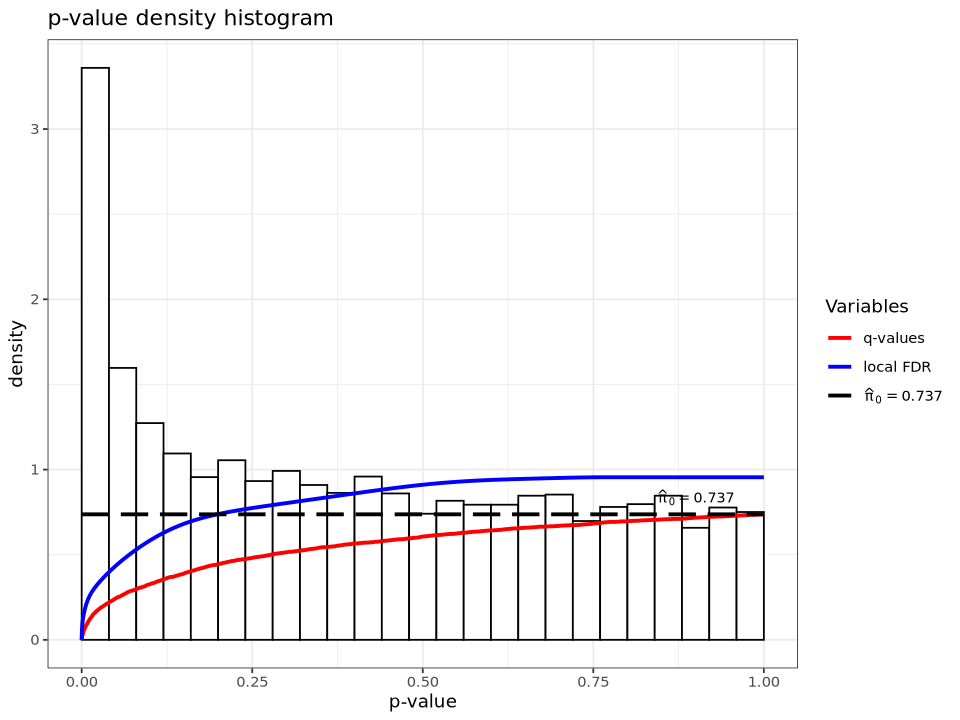

In [ ]:
summary(qobj)

options(repr.plot.width = 8, repr.plot.height = 6)
hist(qobj)

The p-values are relatively flat at the right tail of the histogram. This is an important step in determining
whether the true null p-values are distributed according to a Uniform(0,1) distribution. 

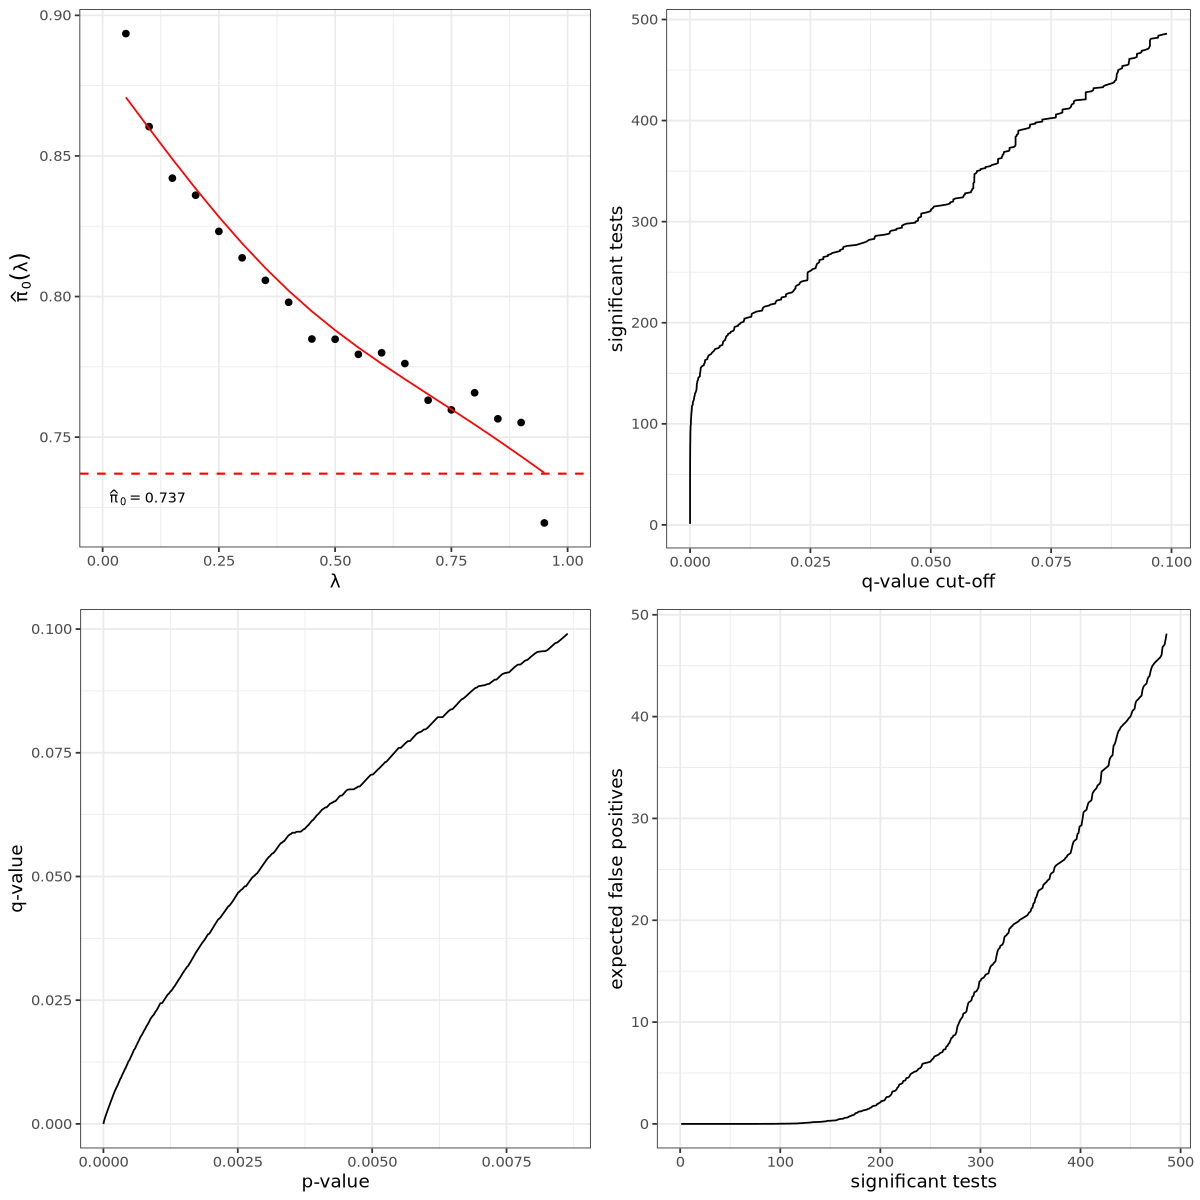

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)
p=plot(qobj)

ggsave(filename = "~/cd4_CellRegMap/002_interaction_analysis/results/results_042426/many_lead_snps_per_gene_res34_5factors/fdr_corrected/qvalue_statistics.png", plot = p, width = 10, height = 10, units = "in", dpi = 300)


Warning message:
“Removed 150 rows containing missing values or values outside the scale range
(`geom_point()`).”


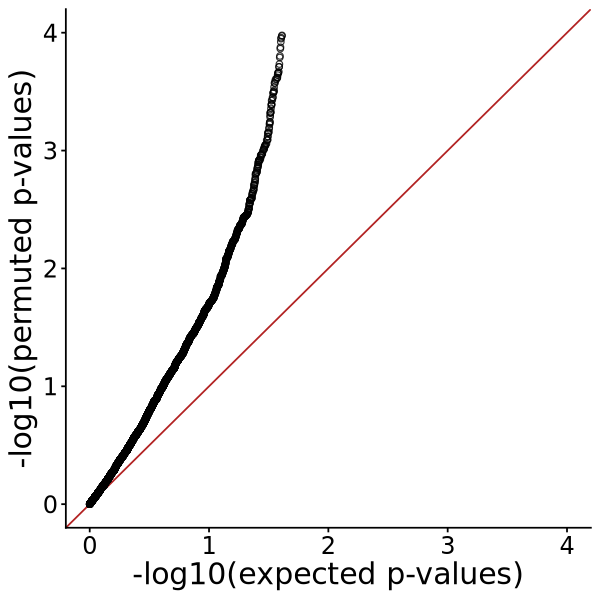

In [ ]:
options(repr.plot.width=5, repr.plot.height=5)
unique_genes$pv_uniform = runif(dim(unique_genes)[1], min = 0, max = 1)
p = ggplot(unique_genes, aes(x = sort(-log10(pv_uniform)), y = sort(-log10(pv_raw)))) + 
    geom_abline(slope = 1, intercept = 0, col = "firebrick") +
    geom_point(alpha = 0.8, pch = 1) + xlab("-log10(expected p-values)") + ylab("-log10(permuted p-values)") +
    theme_classic() + xlim(c(0,4)) + ylim(c(0,4)) +
    theme(legend.position="none", panel.border = element_blank()) + theme(text = element_text(size=18))
p
#ggsave(filename = "~/cd4_CellRegMap/002_interaction_analysis/results/results_042426/many_lead_snps_per_gene_res34_5factors/fdr_corrected/qqplot_statistics.pdf", plot = p, width = 10, height = 10, units = "in", dpi = 300)


In [ ]:
sig=res[res$reject=="True",]
sig <- sig %>%
  arrange(pv_adj) 
#write.csv(sig, "~/cd4_CellRegMap/002_interaction_analysis/results/results_042426/many_lead_snps_per_gene_res34_5factors/fdr_corrected/2026_04_26_cellregmap_interaction_many_lead_snps_fdr05.csv", row.names=FALSE)


In [ ]:
sig

gene,chrom,snpID,pv_raw,n_independent_signals_for_gene,pv_bonf_gene,pv_for_fdr,pv_adj,reject,correction,alpha
<chr>,<int>,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
TTC39C-AS1,18,"18:23999608[b38]CT,C",3.820376e-32,1,3.820376e-32,3.820376e-32,2.888586e-28,True,bonferroni_fdr,0.05
PLEK,2,"2:68405251[b38]T,C",1.533510e-30,1,1.533510e-30,1.533510e-30,5.797434e-27,True,bonferroni_fdr,0.05
ARHGAP15,2,"2:143218530[b38]C,CA",1.756358e-30,3,5.269074e-30,5.269074e-30,1.327982e-26,True,bonferroni_fdr,0.05
ENSG00000288861,22,"22:22747272[b38]A,T",1.241075e-28,1,1.241075e-28,1.241075e-28,2.345942e-25,True,bonferroni_fdr,0.05
TMEM273,10,"10:49184350[b38]A,T",1.542391e-26,2,3.084783e-26,3.084783e-26,4.664808e-23,True,bonferroni_fdr,0.05
RNASET2,6,"6:166976754[b38]A,G",1.901197e-25,4,7.604787e-25,7.604787e-25,9.583299e-22,True,bonferroni_fdr,0.05
CHI3L2,1,"1:111230252[b38]A,AT",2.891506e-23,2,5.783012e-23,5.783012e-23,6.246479e-20,True,bonferroni_fdr,0.05
COL18A1,21,"21:45472632[b38]A,G",4.961633e-21,2,9.923267e-21,9.923267e-21,9.378727e-18,True,bonferroni_fdr,0.05
RETREG1,5,"5:16626313[b38]G,C",5.554519e-20,1,5.554519e-20,5.554519e-20,4.666413e-17,True,bonferroni_fdr,0.05
